# Projekt 03 (final): Nachfrage erklaeren und vorhersagen

**Szenario (Fortsetzung von Modul 02):** Die Betriebsleitung von Capital Bikeshare
war von deiner EDA begeistert. Jetzt will sie mehr:

1. **Erklaeren:** Wie stark haengt die Tagesnachfrage von Wetter und Kalender ab —
   in Zahlen? (→ Regression)
2. **Vorhersagen:** Wie viele Raeder werden morgen gebraucht? (→ Zeitreihen-Prognose)

**Daten: echt** — dieselben Bike-Sharing-Daten (UCI) wie in Modul 02, diesmal die
**Tagesebene** (`day.csv`, 731 Tage 2011-2012). Vorbereitung (einmalig):

```
python daten/download_daten.py
```

**Bezug zum Skript:** Abschnitte 1.1-1.2 (Regression), 2.1 (Zeitreihen),
2.2 (Feature Engineering, Leakage!).

## 1. Daten laden

Entnormierung wie gehabt (`temp*41` = Grad C usw. — Doku lesen zahlt sich aus).

(731, 19)


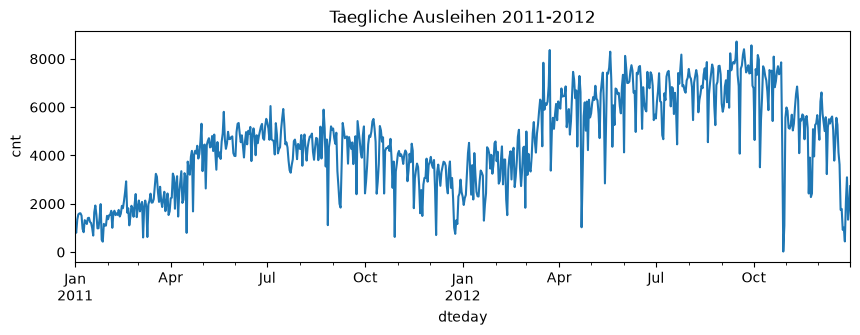

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

PFAD = "daten/day.csv" if os.path.exists("daten/day.csv") else "../daten/day.csv"
df = pd.read_csv(PFAD, parse_dates=["dteday"])
df["temp_c"] = df["temp"] * 41
df["hum_pct"] = df["hum"] * 100
df["wind_kmh"] = df["windspeed"] * 67
print(df.shape)

df.set_index("dteday")["cnt"].plot(figsize=(10, 3), title="Taegliche Ausleihen 2011-2012")
plt.ylabel("cnt"); plt.show()

## 2. Einfache Regression: Nachfrage ~ Temperatur

**Aufgaben:**
1. Fitte `cnt ~ temp_c` mit `LinearRegression` (Achtung: sklearn erwartet X als
   2D — `df[["temp_c"]]`, nicht `df["temp_c"]`).
2. Gib Steigung, Achsenabschnitt und $R^2$ aus und formuliere die Steigung als Satz
   („pro Grad mehr ...").
3. Zeichne Scatter + Regressionsgerade.

Steigung: 162.0 Ausleihen pro Grad C
Achsenabschnitt: 1215
R2: 0.394


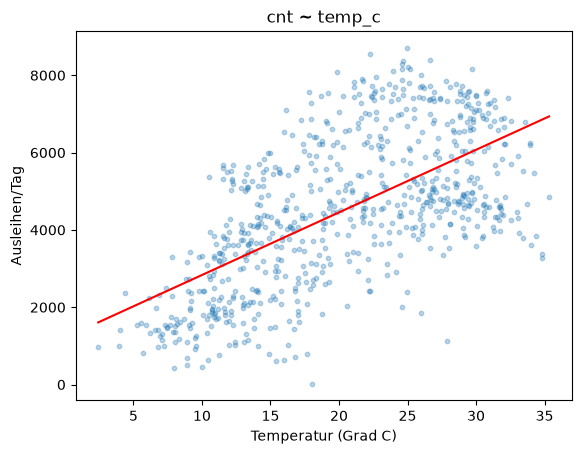

True


In [2]:
X1 = df[["temp_c"]]
y = df["cnt"]
m1 = LinearRegression().fit(X1, y)
print(f"Steigung: {m1.coef_[0]:.1f} Ausleihen pro Grad C")
print(f"Achsenabschnitt: {m1.intercept_:.0f}")
print(f"R2: {m1.score(X1, y):.3f}")

sortiert = X1.sort_values("temp_c")
plt.scatter(df["temp_c"], y, alpha=0.3, s=10)
plt.plot(sortiert["temp_c"], m1.predict(sortiert), color="red")
plt.xlabel("Temperatur (Grad C)"); plt.ylabel("Ausleihen/Tag"); plt.title("cnt ~ temp_c")
plt.show()

# Mini-Check: R2 ~ r^2 aus Modul 02 (r war 0.627)
print(0.35 < m1.score(X1, y) < 0.45)

## 3. Residuenanalyse — dem Modell auf die Finger schauen

**Aufgabe:** Plotte die Residuen ($y - \hat{y}$) gegen die Temperatur.
Siehst du eine Kruemmung? Was sagt sie inhaltlich? (Skript 1.1: Residuenplot!)

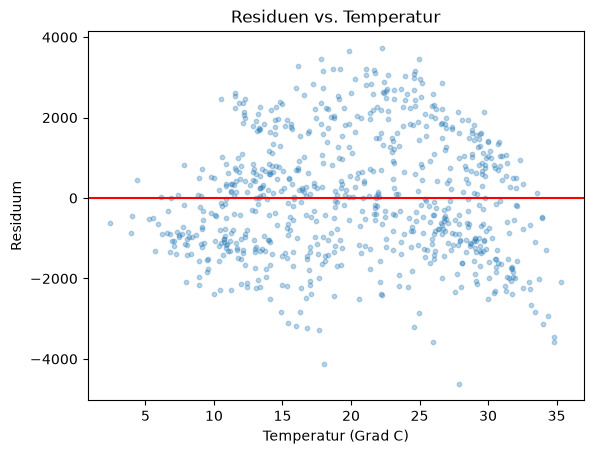

In [3]:
residuen = y - m1.predict(X1)
plt.scatter(df["temp_c"], residuen, alpha=0.3, s=10)
plt.axhline(0, color="red")
plt.xlabel("Temperatur (Grad C)"); plt.ylabel("Residuum"); plt.title("Residuen vs. Temperatur")
plt.show()

**Befund:** Umgekehrte U-Form — bei milden Temperaturen unterschaetzt die Gerade,
an sehr heissen Tagen ueberschaetzt sie. Inhaltlich klar: **ab ~30 Grad macht Radfahren
keinen Spass mehr.** Eine Gerade kann „erst rauf, dann runter" nicht abbilden.

**Aufgabe:** Ergaenze `temp_c2 = temp_c**2` als Feature und fitte
`cnt ~ temp_c + temp_c2`. Vergleiche $R^2$ und berechne den **Scheitelpunkt**
$-\beta_1 / (2\beta_2)$ — die rechnerische Wohlfuehltemperatur.

In [4]:
df["temp_c2"] = df["temp_c"] ** 2
X2 = df[["temp_c", "temp_c2"]]
m2 = LinearRegression().fit(X2, y)
scheitel = -m2.coef_[0] / (2 * m2.coef_[1])
print(f"R2 linear: {m1.score(X1, y):.3f}  ->  quadratisch: {m2.score(X2, y):.3f}")
print(f"Wohlfuehltemperatur (Scheitel): {scheitel:.1f} Grad C")

# Mini-Check:
print(25 < scheitel < 31)

R2 linear: 0.394  ->  quadratisch: 0.453
Wohlfuehltemperatur (Scheitel): 29.1 Grad C
True


## 4. Multiple Regression: das Erklaerungsmodell

**Aufgabe:** Fitte `cnt ~ temp_c + temp_c2 + hum_pct + wind_kmh + workingday + yr`
und interpretiere JEDEN Koeffizienten in einem Satz — **ceteris paribus** (Skript 1.2!).
`yr` ist dabei besonders interessant (0 = 2011, 1 = 2012): Was misst er?

In [5]:
FEATURES_ERKLAER = ["temp_c", "temp_c2", "hum_pct", "wind_kmh", "workingday", "yr"]
m3 = LinearRegression().fit(df[FEATURES_ERKLAER], y)
print(f"R2: {m3.score(df[FEATURES_ERKLAER], y):.3f}\n")
for name, koeff in zip(FEATURES_ERKLAER, m3.coef_):
    print(f"{name:>12}: {koeff:>9.1f}")

R2: 0.794

      temp_c:     555.9
     temp_c2:     -10.0
     hum_pct:     -32.3
    wind_kmh:     -77.0
  workingday:      97.7
          yr:    1893.1


**Musterinterpretation (mit deiner vergleichen):**

- `hum_pct` ≈ −32: pro Prozentpunkt Luftfeuchte ~32 Ausleihen weniger (bei sonst gleichen Bedingungen)
- `wind_kmh` ≈ −77: Wind schreckt deutlich ab
- `workingday` ≈ +98: Arbeitstage bringen auf Tagesebene etwas mehr Volumen (die Pendler!)
- `yr` ≈ +1893: **2012 lagen die Tage im Schnitt ~1900 Ausleihen ueber 2011** — das ist
  der Wachstumstrend als Zahl. Ohne `yr` wuerde dieser Trend in die anderen
  Koeffizienten „einsickern" (Omitted Variable Bias!)
- `temp_c`/`temp_c2` einzeln zu interpretieren ist sinnlos (Multikollinearitaet
  zwischen $x$ und $x^2$ ist hier gewollt) — sie wirken nur *gemeinsam* als Parabel.

**Warnung vor Kausal-Sprech:** „+98 an Arbeitstagen" ist eine *Beschreibung* der Daten,
kein Experiment. Fuer Kausalaussagen fehlen uns Confounder-Kontrolle und Randomisierung.

## 5. Prognose: morgen frueh wissen, was heute Abend fehlt

Jetzt der Wechsel von **erklaeren** zu **vorhersagen** — mit den Regeln aus Skript 2.1/2.2:

- **Lag-Features:** `lag1` (gestern), `lag7` (vor einer Woche), `roll7`
  (Mittel der letzten 7 Tage, um einen Tag versetzt — warum das `.shift(1)` braucht,
  ist die Leakage-Frage unten!)
- **Zeitlicher Split:** Training bis 30.09.2012, Test ab 01.10.2012 (92 Tage)
- **Baselines zuerst:** naiv (= gestern) und saisonal-naiv (= vor 7 Tagen)
- **Metrik:** MAE (mittlerer absoluter Fehler — direkt in „Raedern" interpretierbar)

**Aufgabe:** Baue die drei Lag-Features, splitte zeitlich, berechne die MAE der
beiden Baselines und trainiere dann eine `LinearRegression` auf
Wetter + Kalender + Lags. Schlaegt sie die Baselines?

In [6]:
df["lag1"] = df["cnt"].shift(1)
df["lag7"] = df["cnt"].shift(7)
df["roll7"] = df["cnt"].shift(1).rolling(7).mean()
dd = df.dropna().reset_index(drop=True)

FEATURES = FEATURES_ERKLAER + ["lag1", "lag7", "roll7"]
train = dd[dd["dteday"] < "2012-10-01"]
test = dd[dd["dteday"] >= "2012-10-01"]

mae_naiv = mean_absolute_error(test["cnt"], test["lag1"])
mae_saison = mean_absolute_error(test["cnt"], test["lag7"])

modell = LinearRegression().fit(train[FEATURES], train["cnt"])
prognose = modell.predict(test[FEATURES])
mae_modell = mean_absolute_error(test["cnt"], prognose)

print(f"Testzeitraum: {len(test)} Tage")
print(f"MAE naiv (gestern):        {mae_naiv:7.0f} Raeder")
print(f"MAE saisonal (vor 7 T.):   {mae_saison:7.0f} Raeder")
print(f"MAE Regressionsmodell:     {mae_modell:7.0f} Raeder")

# Mini-Check: Modell schlaegt beide Baselines
print(mae_modell < mae_naiv < mae_saison)

Testzeitraum: 92 Tage
MAE naiv (gestern):            952 Raeder
MAE saisonal (vor 7 T.):      1458 Raeder
MAE Regressionsmodell:         859 Raeder
True


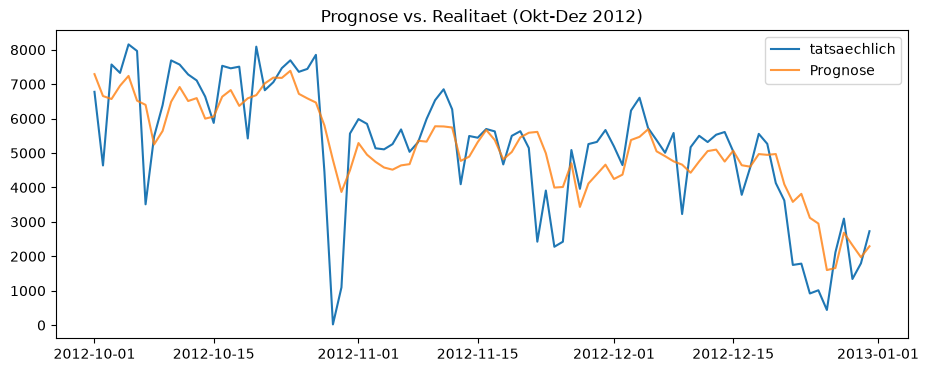

,dteday,cnt,fehler,weathersit
660,2012-10-29,22,4776.454979,3
684,2012-11-22,2425,3189.732578,1
638,2012-10-07,3510,2888.788350,2


In [7]:
plt.figure(figsize=(11, 4))
plt.plot(test["dteday"], test["cnt"].values, label="tatsaechlich")
plt.plot(test["dteday"], prognose, label="Prognose", alpha=0.8)
plt.title("Prognose vs. Realitaet (Okt-Dez 2012)"); plt.legend(); plt.show()

schlechteste = test.assign(fehler=(test["cnt"] - prognose).abs()).nlargest(3, "fehler")
schlechteste[["dteday", "cnt", "fehler", "weathersit"]]

**Schau auf die schlechtesten Tage:** Ende Oktober 2012 bricht die Nachfrage auf
fast Null ein — das ist **Hurrikan Sandy** (29./30.10.2012, Washington D.C. stand
still). Kein Modell der Welt sagt so etwas aus Lag-Features vorher. Reale Prognosen
brauchen deshalb externe Informationen (Wetterwarnungen, Events) — und ehrliche
Fehlerangaben, die solche Tage einschliessen.

## 6. Die Leakage-Demo: Warum der zeitliche Split nicht verhandelbar ist

**Aufgabe:** Trainiere dasselbe Modell mit einem **zufaelligen** 75/25-Split
(`train_test_split`, `random_state=0`) und vergleiche die Test-MAE mit deinem
zeitlichen Split. Erklaere den Unterschied. (Skript 2.2: Leakage!)

In [8]:
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(dd[FEATURES], dd["cnt"], test_size=0.25, random_state=0)
m_zufall = LinearRegression().fit(X_tr, y_tr)
mae_zufall = mean_absolute_error(y_te, m_zufall.predict(X_te))
print(f"MAE zeitlicher Split: {mae_modell:.0f}")
print(f"MAE zufaelliger Split: {mae_zufall:.0f}  <- sieht besser aus, ist aber gelogen!")

MAE zeitlicher Split: 859
MAE zufaelliger Split: 625  <- sieht besser aus, ist aber gelogen!


**Erklaerung:** Beim Zufalls-Split stehen Trainingstage zeitlich ZWISCHEN den
Testtagen — das Modell kennt fuer einen Testtag oft den Vortag und den Folgetag aus
dem Training, und die Lag-Features tragen deren Information direkt hinein. Die ~625
sind keine Prognoseleistung, sondern ein Messartefakt. Der ehrliche Wert ist der
zeitliche Split (~860): **So gut waeren wir wirklich gewesen, haetten wir ab Oktober
2012 jeden Tag prognostiziert.**

## 7. Fazit an die Betriebsleitung

**Aufgabe:** Wieder 4-5 Bullet-Points in Alltagssprache: Was treibt die Nachfrage
(mit Zahlen!), wie gut koennen wir morgen vorhersagen, wo sind die Grenzen?

<details><summary>Musterfazit</summary>

- Temperatur ist der staerkste Hebel: Nachfrage steigt bis ~28 Grad und faellt darueber wieder — Hitzetage sind KEINE Spitzentage.
- Wind und hohe Luftfeuchte druecken die Nachfrage spuerbar (~77 bzw. ~32 Ausleihen je Einheit).
- Das Geschaeft ist 2012 um im Schnitt ~1.900 Ausleihen/Tag gegenueber 2011 gewachsen — Kapazitaetsplanung muss diesen Trend fortschreiben.
- Unsere Tagesprognose liegt im Schnitt ~860 Raeder daneben (bei 2.000-8.000 Ausleihen/Tag) und schlaegt einfache Faustregeln („wie gestern": ~950).
- Grenzen: Extremereignisse (Hurrikan Sandy) sind aus Verlaufsdaten nicht vorhersagbar — fuer solche Tage braucht es Wetterwarnungen im Prozess.
</details>

## Geschafft — was du jetzt kannst

- Regression als Erklaerungswerkzeug: Koeffizienten ceteris paribus lesen,
  $R^2$ einordnen, Residuen pruefen, Nichtlinearitaet per Quadratterm einfangen
- Regression als Prognosewerkzeug: Lag-Features, zeitlicher Split, Baselines, MAE
- Leakage nicht nur benennen, sondern **in Zahlen vorfuehren**
- Modellgrenzen ehrlich kommunizieren (Sandy!)

**Bonusaufgaben:**
1. Sin/Cos-Kodierung des Monats (Skript 2.2) statt `yr` + Saison-Dummies — hilft es?
2. Berechne die MAE getrennt fuer Okt/Nov/Dez — wird die Prognose zum Jahresende schlechter? Warum koennte das sein?
3. Standardisiere die Features und vergleiche die Koeffizienten — welche Variable hat jetzt den groessten Betrag, und warum ist das die fairere Vergleichsbasis?

---

**Modul 03 ist damit abgeschlossen.** Weiter geht es mit Machine Learning 1 —
dort wird aus „Regression fitten" ein systematischer Werkzeugkasten mit
Validierung, Regularisierung und vielen weiteren Modellfamilien.